# More of the tour

These sections carry on from *A Tour of a Notebook* — data that arrives messy,
a function worth testing, two classes doing real mathematics, and a benchmark.
They are self-contained: the setup cell below is the same one the main notebook
opens with, so this file runs on its own, and the section cells can be pasted
straight across.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

rng = np.random.default_rng(7)

# One palette, used by name everywhere below.
INK, MUTED = "#0b0b0b", "#52514e"
SERIES = {"Reykjavik": "#2a78d6", "Lisbon": "#eb6834", "Nairobi": "#1baf7a"}
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
blue = LinearSegmentedColormap.from_list("blue", BLUES)
divergent = LinearSegmentedColormap.from_list("bwr", ["#184f95", "#f0efec", "#d03b3b"])

plt.rcParams.update({
    "figure.figsize": (5.2, 3.4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": MUTED,
    "axes.titlecolor": INK,
    "axes.titlelocation": "left",
    "axes.titleweight": "semibold",
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "legend.frameon": False,
})

In [2]:
from io import StringIO

RAW = StringIO("""\
station,date,temp_c,wind,status
KEF,2026-03-01,3.1,12 kph,ok
KEF,2026-03-02,-999,18 kph,sensor fault
KEF,2026-03-03,4.6,9 kph,ok
KEF,2026-03-03,4.6,9 kph,ok
LIS,2026-03-01,16.2,21 kph,ok
LIS,2026-03-02,17.8,-999,ok
LIS,2026-03-03,18.1,14 kph,ok
NBO,2026-03-01,24.9,7 kph,ok
NBO,2026-03-02,25.4,11 kph,ok
NBO,2026-03-03,-999,8 kph,sensor fault
""")

readings = pd.read_csv(RAW, parse_dates=["date"], na_values=[-999])
readings

,station,date,temp_c,wind,status
0,KEF,2026-03-01,3.1,12 kph,ok
1,KEF,2026-03-02,NaN,18 kph,sensor fault
2,KEF,2026-03-03,4.6,9 kph,ok
3,KEF,2026-03-03,4.6,9 kph,ok
4,LIS,2026-03-01,16.2,21 kph,ok
5,LIS,2026-03-02,17.8,NaN,ok
6,LIS,2026-03-03,18.1,14 kph,ok
7,NBO,2026-03-01,24.9,7 kph,ok
8,NBO,2026-03-02,25.4,11 kph,ok
9,NBO,2026-03-03,NaN,8 kph,sensor fault


## 7 · Importing data, and the mess it arrives in

Data almost never lands ready to use. This CSV has the usual problems: dates
as strings, a sentinel for "missing", a stray unit suffix, and duplicate rows.
The cleaning is a pipeline of small named steps, each one a function you can
read, test and reorder.

In [3]:
def drop_duplicates(df):
    """The logger occasionally repeats a row."""
    return df.drop_duplicates()


def strip_units(df):
    """`wind` arrives as '12 kph'; keep the number."""
    return df.assign(wind=df.wind.str.removesuffix(" kph").astype(float))


def flag_faults(df):
    """A fault is a missing reading, whatever the status column says."""
    return df.assign(faulty=df.temp_c.isna() | df.wind.isna())


def interpolate_gaps(df):
    """Fill each station's gaps from its own neighbours in time."""
    numeric = ["temp_c", "wind"]
    filled = df.groupby("station")[numeric].transform(
        lambda s: s.interpolate(limit_direction="both")
    )
    return df.assign(**filled)


PIPELINE = [drop_duplicates, strip_units, flag_faults, interpolate_gaps]

In [4]:
def run(df, steps):
    """Apply each step in turn, recording what it did to the frame."""
    log = [("raw", len(df), int(df.isna().sum().sum()))]
    for step in steps:
        df = step(df)
        log.append((step.__name__, len(df), int(df.isna().sum().sum())))
    return df, pd.DataFrame(log, columns=["step", "rows", "missing"])


clean, journal = run(readings, PIPELINE)
journal

,step,rows,missing
0,raw,10,3
1,drop_duplicates,9,3
2,strip_units,9,3
3,flag_faults,9,3
4,interpolate_gaps,9,0


In [5]:
clean.pivot_table(index="date", columns="station", values="temp_c").round(1)

station,KEF,LIS,NBO
date,,,
2026-03-01,3.1,16.2,24.9
2026-03-02,3.8,17.8,25.4
2026-03-03,4.6,18.1,25.4


## 8 · A function worth testing

Bisection brackets a root and halves the bracket until it is small enough.
It converges slowly but it cannot fail: if $f(a)$ and $f(b)$ have opposite
signs and $f$ is continuous, a root is in there somewhere.

In [6]:
def bisect(f, lo, hi, tol=1e-12, max_steps=200):
    """Find x in [lo, hi] with f(x) = 0, returning it and the bracket widths."""
    if f(lo) * f(hi) > 0:
        raise ValueError(f"f does not change sign on [{lo}, {hi}]")

    widths, guesses = [], []
    for _ in range(max_steps):
        mid = (lo + hi) / 2
        if f(lo) * f(mid) <= 0:
            hi = mid
        else:
            lo = mid
        widths.append(hi - lo)
        guesses.append((lo + hi) / 2)
        if hi - lo < tol:
            break
    return (lo + hi) / 2, np.array(widths), np.array(guesses)


root, widths, guesses = bisect(lambda x: x**2 - 2, 0, 2)
print(f"sqrt(2) ~= {root:.15f}   (error {abs(root - np.sqrt(2)):.2e})")

sqrt(2) ~= 1.414213562372879   (error 2.16e-13)


In [7]:
def check(name, got, want, tol=1e-9):
    """One assertion, recorded rather than raised, so every case reports."""
    ok = abs(got - want) < tol
    return {"case": name, "got": got, "want": want, "pass": "PASS" if ok else "FAIL"}


cases = [
    check("x^2 - 2 on [0, 2]", bisect(lambda x: x**2 - 2, 0, 2)[0], np.sqrt(2)),
    check("cos x - x on [0, 1]", bisect(lambda x: np.cos(x) - x, 0, 1)[0], 0.7390851332),
    check("x^3 on [-1, 2]", bisect(lambda x: x**3, -1, 2)[0], 0.0),
    check("sin x on [3, 4]", bisect(np.sin, 3, 4)[0], np.pi),
]

results = pd.DataFrame(cases)
assert (results["pass"] == "PASS").all(), results
results

,case,got,want,pass
0,"x^2 - 2 on [0, 2]",1.414214e+00,1.414214,PASS
1,"cos x - x on [0, 1]",7.390851e-01,0.739085,PASS
2,"x^3 on [-1, 2]",1.136868e-13,0.000000,PASS
3,"sin x on [3, 4]",3.141593e+00,3.141593,PASS


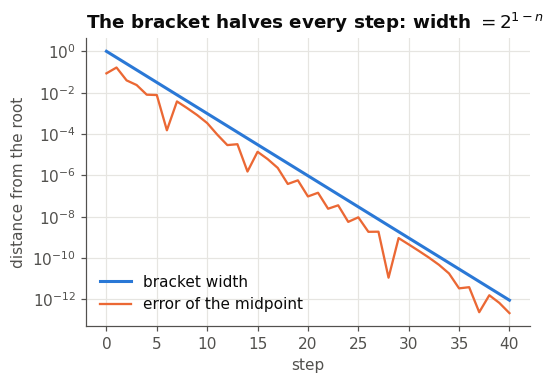

In [8]:
fig, ax = plt.subplots()
ax.semilogy(widths, color=SERIES["Reykjavik"], lw=2, label="bracket width")
ax.semilogy(np.maximum(abs(guesses - np.sqrt(2)), 1e-17), color=SERIES["Lisbon"],
            lw=1.5, label="error of the midpoint")
ax.set(title=r"The bracket halves every step: width $= 2^{1-n}$",
       xlabel="step", ylabel="distance from the root")
ax.legend(loc="lower left")
plt.show()

## 9 · Cauchy's integral formula



In [9]:
class Contour:
    """A circle in the complex plane, and the integrals taken around it."""

    def __init__(self, centre=0j, radius=1.0, nodes=256):
        self.centre = complex(centre)
        self.radius = float(radius)
        self.t = np.linspace(0, 2 * np.pi, nodes, endpoint=False)

    @property
    def z(self):
        """The sample points on the contour."""
        return self.centre + self.radius * np.exp(1j * self.t)

    @property
    def dz(self):
        """dz/dt at each sample point."""
        return 1j * self.radius * np.exp(1j * self.t)

    def integrate(self, g):
        """The contour integral of g, by the trapezoid rule in t."""
        return 2 * np.pi * np.mean(g(self.z) * self.dz)

    def cauchy(self, f, z0):
        """f(z0), recovered from the values of f on the contour."""
        return self.integrate(lambda z: f(z) / (z - z0)) / (2j * np.pi)

    def winding(self, z0):
        """How many times the contour encircles z0 -- 1 inside, 0 outside."""
        return round(self.integrate(lambda z: 1 / (z - z0)).imag / (2 * np.pi))


unit = Contour(radius=1.0, nodes=64)
z0 = 0.3 + 0.2j

print(f"exp(z0) from the boundary : {unit.cauchy(np.exp, z0):.12f}")
print(f"exp(z0) directly          : {np.exp(z0):.12f}")
print(f"winding number about z0   : {unit.winding(z0)}")

exp(z0) from the boundary : 1.322951502110+0.268175545969j
exp(z0) directly          : 1.322951502110+0.268175545969j
winding number about z0   : 1


For $f$ holomorphic inside and on a simple closed contour $C$, the value at
any interior point is fixed by the values on the boundary alone:

$$f(z_0) \;=\; \frac{1}{2\pi i}\oint_C \frac{f(z)}{z - z_0}\,dz$$

Take $C$ to be the circle $z(t) = c + re^{it}$. Then $dz = i r e^{it}\,dt$ and
the contour integral becomes an ordinary integral over $t \in [0, 2\pi)$:

$$\oint_C g(z)\,dz \;=\; i r \int_0^{2\pi} g\big(z(t)\big)\, e^{it}\,dt$$

The integrand is periodic and smooth, and for that case the trapezoid rule is
not merely second order — it converges *geometrically*. A few dozen points
reach machine precision.

In [10]:
# The residue theorem, as a check: 1/(z^2+1) has a simple pole at z = i with
# residue 1/(2i), so a circle drawn around it must integrate to 2*pi*i/(2i) = pi.
around_i = Contour(centre=1j, radius=0.5, nodes=64)
value = around_i.integrate(lambda z: 1 / (z**2 + 1))

print(f"contour integral : {value:.12f}")
print(f"2*pi*i * residue : {np.pi:.12f}")
assert abs(value - np.pi) < 1e-10
assert around_i.winding(-1j) == 0, "the other pole is outside this circle"

contour integral : 3.141592653590-0.000000000000j
2*pi*i * residue : 3.141592653590


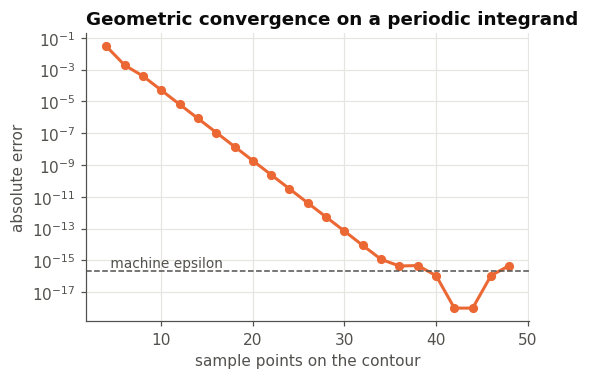

In [11]:
nodes = np.arange(4, 49, 2)
error = [
    abs(Contour(radius=1.0, nodes=n).cauchy(np.exp, z0) - np.exp(z0))
    for n in nodes
]

fig, ax = plt.subplots()
ax.semilogy(nodes, np.maximum(error, 1e-18), "o-", color=SERIES["Lisbon"],
            lw=2, ms=5)
ax.axhline(np.finfo(float).eps, color=MUTED, lw=1, ls="--")
ax.text(nodes[0], np.finfo(float).eps * 1.8, " machine epsilon",
        color=MUTED, ha="left", fontsize=9)
ax.set(title="Geometric convergence on a periodic integrand",
       xlabel="sample points on the contour", ylabel="absolute error")
plt.show()

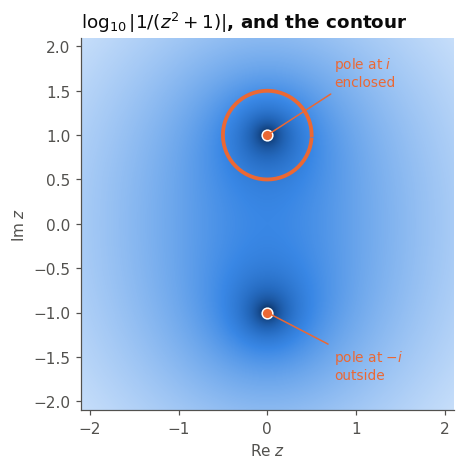

In [12]:
axis = np.linspace(-2.1, 2.1, 400)
z = axis[None, :] + 1j * axis[:, None]
field = 1 / (z**2 + 1)

fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.imshow(np.log10(np.abs(field)), cmap=blue, extent=(-2.1, 2.1, -2.1, 2.1),
          origin="lower", vmin=-1.0, vmax=1.0)
ax.plot(around_i.z.real, around_i.z.imag, color=SERIES["Lisbon"], lw=2.5)
ax.plot([0, 0], [1, -1], "o", color="#eb6834", ms=7, mec="white", mew=1)
ax.annotate("pole at $i$\nenclosed", (0, 1), (0.75, 1.55), color="#eb6834",
            fontsize=9, arrowprops=dict(arrowstyle="-", color="#eb6834", lw=1))
ax.annotate("pole at $-i$\noutside", (0, -1), (0.75, -1.75), color="#eb6834",
            fontsize=9, arrowprops=dict(arrowstyle="-", color="#eb6834", lw=1))
ax.set(title=r"$\log_{10}|1/(z^2+1)|$, and the contour",
       xlabel="Re $z$", ylabel="Im $z$")
ax.grid(False)
plt.show()

## 10 · A field equation, integrated step by step

Heat spreads by the diffusion equation,

$$\frac{\partial u}{\partial t} \;=\; \alpha\, \nabla^2 u ,
\qquad \nabla^2 u \;=\; \frac{\partial^2 u}{\partial x^2}
                       + \frac{\partial^2 u}{\partial y^2}$$

On a square grid the Laplacian is the five-point stencil — each cell against
the average of its four neighbours:

$$\nabla^2 u_{ij} \;\approx\;
  \frac{u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} - 4u_{ij}}{h^2}$$

Explicit stepping is only stable while $\alpha\,\Delta t / h^2 \le 1/4$, so the
class refuses to be built outside that bound rather than quietly producing
noise.

In [13]:
class Plate:
    """A square plate cooling towards a cold rim, stepped explicitly."""

    def __init__(self, size=128, alpha=1.0, dt=0.2, h=1.0):
        if alpha * dt / h**2 > 0.25:
            raise ValueError("unstable: need alpha*dt/h^2 <= 1/4")
        self.u = np.zeros((size, size))
        self.rate = alpha * dt / h**2
        self.time = 0.0

    def heat(self, row, col, radius, amount=1.0):
        """Add a disc of heat, centred on (row, col)."""
        y, x = np.ogrid[: self.u.shape[0], : self.u.shape[1]]
        self.u[(y - row) ** 2 + (x - col) ** 2 <= radius**2] += amount
        return self

    def laplacian(self):
        u = self.u
        return (
            np.roll(u, 1, 0) + np.roll(u, -1, 0)
            + np.roll(u, 1, 1) + np.roll(u, -1, 1)
            - 4 * u
        )

    def step(self):
        self.u += self.rate * self.laplacian()
        self.u[0, :] = self.u[-1, :] = self.u[:, 0] = self.u[:, -1] = 0
        self.time += 1
        return self

    def run(self, steps):
        for _ in range(steps):
            self.step()
        return self

    @property
    def energy(self):
        """Total heat left on the plate."""
        return self.u.sum()


plate = Plate(size=128).heat(40, 40, 10).heat(90, 85, 14).heat(45, 95, 6)
print(f"stability number alpha*dt/h^2 = {plate.rate}")
print(f"energy at t=0: {plate.energy:.1f}")

stability number alpha*dt/h^2 = 0.2
energy at t=0: 1043.0


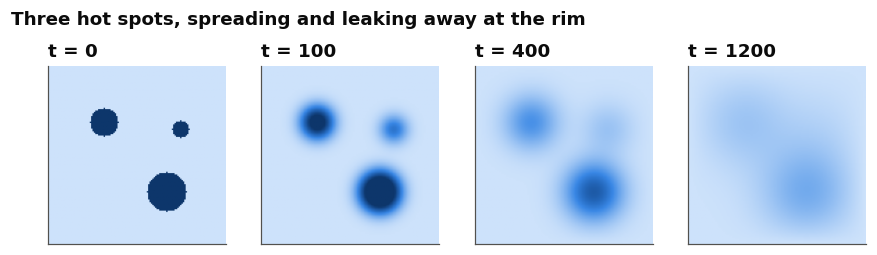

In [14]:
snapshots = {}
history = []
for t in range(1201):
    if t in (0, 100, 400, 1200):
        snapshots[t] = plate.u.copy()
    history.append(plate.energy)
    plate.step()

fig, axes = plt.subplots(1, 4, figsize=(9.6, 2.7))
for ax, (t, frame) in zip(axes, snapshots.items()):
    ax.imshow(frame, cmap=blue, vmin=0, vmax=0.6)
    ax.set(title=f"t = {t}", xticks=[], yticks=[])
    ax.grid(False)
fig.suptitle("Three hot spots, spreading and leaking away at the rim",
             x=0.09, ha="left", fontweight="semibold")
plt.show()

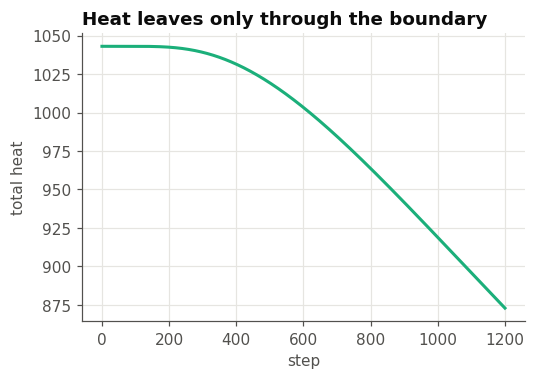

In [15]:
fig, ax = plt.subplots()
ax.plot(history, color=SERIES["Nairobi"], lw=2)
ax.set(title="Heat leaves only through the boundary", xlabel="step",
       ylabel="total heat")
plt.show()

## 11 · How fast is fast

The same sum of squared distances, written four ways. Timing beats guessing:
the loop and the comprehension are doing identical work, and `einsum` earns
its keep only once the arrays are large enough to notice.

In [16]:
import timeit

points = rng.random((600, 3))


def with_loop(p):
    total = 0.0
    for i in range(len(p)):
        for k in range(3):
            total += p[i, k] ** 2
    return total


def with_comprehension(p):
    return sum(v**2 for row in p for v in row)


def with_numpy(p):
    return (p**2).sum()


def with_einsum(p):
    return np.einsum("ij,ij->", p, p)


WAYS = [with_loop, with_comprehension, with_numpy, with_einsum]
expected = with_numpy(points)
assert all(abs(way(points) - expected) < 1e-9 for way in WAYS)

In [17]:
timings = pd.DataFrame(
    {
        "way": [way.__name__ for way in WAYS],
        "seconds": [
            min(timeit.repeat(lambda w=way: w(points), number=5, repeat=3)) / 5
            for way in WAYS
        ],
    }
).sort_values("seconds")
timings["x faster"] = (timings.seconds.max() / timings.seconds).round(1)
timings.set_index("way")

,seconds,x faster
way,,
with_einsum,0.000003,91.2
with_numpy,0.000005,58.0
with_loop,0.000177,1.5
with_comprehension,0.000263,1.0


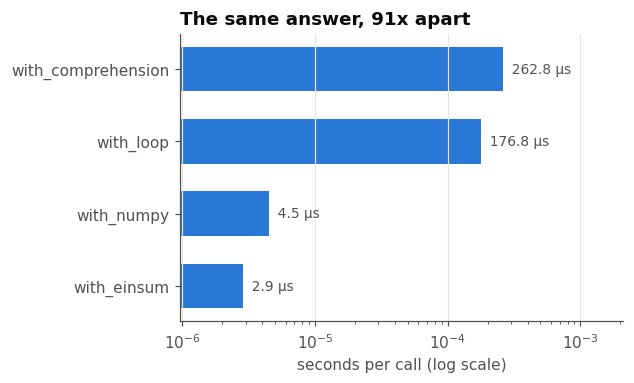

In [18]:
spread = timings.seconds.max() / timings.seconds.min()

fig, ax = plt.subplots()
bars = ax.barh(timings.way, timings.seconds, color=SERIES["Reykjavik"],
               height=0.62)
ax.bar_label(bars, labels=[f"  {s * 1e6:,.1f} \u00b5s" for s in timings.seconds],
             color=MUTED, fontsize=9)
ax.set(title=f"The same answer, {spread:.0f}x apart",
       xlabel="seconds per call (log scale)", xscale="log",
       xlim=(timings.seconds.min() / 3, timings.seconds.max() * 8))
ax.grid(axis="y", visible=False)
plt.show()

## 12 · Two optimizers, one valley

The Rosenbrock function is the classic test for anything that walks downhill:
a long, curved, nearly flat valley whose floor slopes only gently toward the
minimum at $(1, 1)$.

$$f(x, y) \;=\; (1 - x)^2 + 100\,(y - x^2)^2$$

Everything the two experiments share — the function, its gradient, the harness
that records a walk, and the picture — is built once, here. Each column then
defines its own strategy, runs it from the same start with the same step size
and the same budget, and shows what it did.

In [19]:
def rosenbrock(p):
    x, y = p
    return (1 - x) ** 2 + 100 * (y - x**2) ** 2


def gradient(p):
    x, y = p
    return np.array([-2 * (1 - x) - 400 * x * (y - x**2), 200 * (y - x**2)])


START = np.array([-1.5, 1.5])
BUDGET = 4000  # steps each strategy is allowed
LR = 0.002  # and the step size each is given

In [20]:
class Descent:
    """Walks downhill from START one step at a time, keeping every footprint."""

    def __init__(self, lr=LR):
        self.lr = lr

    def step(self, p, g):
        raise NotImplementedError("a strategy says how one step is taken")

    def run(self, steps=BUDGET):
        p = START.copy()
        path = [p]
        for _ in range(steps):
            p = self.step(p, gradient(p))
            path.append(p)
        return np.array(path)


def checkpoints(path, at=(0, 10, 100, 1000, BUDGET)):
    """Where the walk was at a few chosen steps."""
    rows = [(k, *path[k].round(4), rosenbrock(path[k])) for k in at]
    return pd.DataFrame(rows, columns=["step", "x", "y", "f"]).set_index("step")


def draw(path, title, color):
    """The valley as contours, and the path taken across it."""
    X, Y = np.meshgrid(np.linspace(-2, 2, 300), np.linspace(-1, 3, 300))
    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    ax.contourf(X, Y, np.log10(rosenbrock((X, Y)) + 1), levels=30, cmap=blue)
    ax.plot(path[:, 0], path[:, 1], color=color, lw=1.4)
    ax.plot(*START, "o", color=color, ms=6, mec="white")
    ax.plot(1, 1, "*", color="#d03b3b", ms=12, mec="white")
    ax.set(title=title, xlabel="x", ylabel="y")
    ax.grid(False)
    plt.show()

# Two Experiments, Side-by-Side Comparison

### A · Plain gradient descent

Step straight down the gradient. Simple, and famously bad at curved valleys:
every step overshoots the floor, and the walk spends its budget zigzagging.

In [21]:
class GradientDescent(Descent):
    def step(self, p, g):
        return p - self.lr * g


gd_path = GradientDescent().run()
print(f"after {BUDGET} steps: {gd_path[-1].round(4)}   f = {rosenbrock(gd_path[-1]):.2e}")

after 4000 steps: [0.9832 0.9666]   f = 2.83e-04


In [22]:
checkpoints(gd_path)

,x,y,f
step,,,
0,-1.5000,1.5000,62.500000
10,-1.0885,0.9293,10.891180
100,-0.7988,0.6462,3.242201
1000,0.7316,0.5341,0.072170
4000,0.9832,0.9666,0.000283


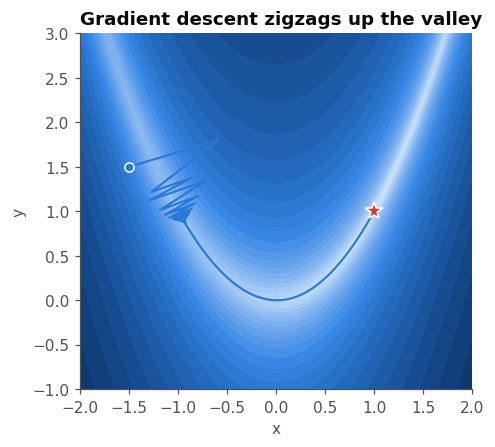

In [23]:
draw(gd_path, "Gradient descent zigzags up the valley", SERIES["Reykjavik"])

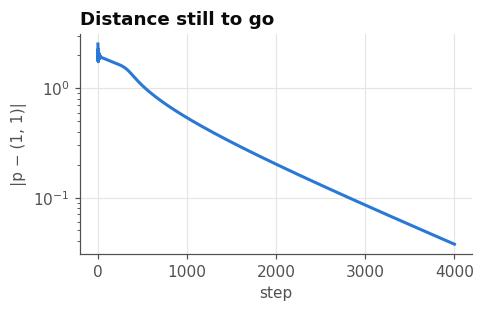

In [24]:
fig, ax = plt.subplots(figsize=(4.6, 2.6))
ax.semilogy(np.maximum(np.linalg.norm(gd_path - [1, 1], axis=1), 1e-16),
            color=SERIES["Reykjavik"], lw=2)
ax.set(title="Distance still to go", xlabel="step", ylabel="|p − (1, 1)|")
plt.show()

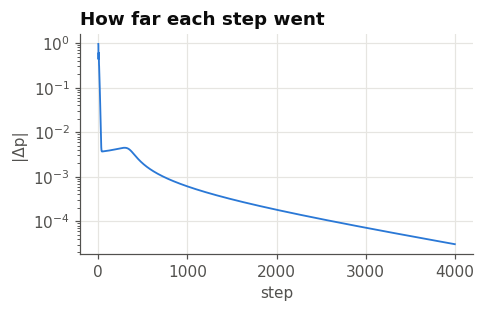

In [25]:
stride = np.linalg.norm(np.diff(gd_path, axis=0), axis=1)

fig, ax = plt.subplots(figsize=(4.6, 2.6))
ax.semilogy(np.maximum(stride, 1e-16), color=SERIES["Reykjavik"], lw=1.2)
ax.set(title="How far each step went", xlabel="step", ylabel="|Δp|")
plt.show()

In [26]:
# The same walk at other step sizes: where does this strategy stop working?
rates = [0.0005, 0.001, 0.002, 0.003, 0.004]
with np.errstate(over="ignore", invalid="ignore"):
    final = [rosenbrock(GradientDescent(lr).run(2000)[-1]) for lr in rates]

pd.DataFrame(
    {"lr": rates,
     "f after 2000 steps": [f"{v:.2e}" if np.isfinite(v) else "diverged" for v in final]}
).set_index("lr")

,f after 2000 steps
lr,
0.0005,1.46e+00
0.0010,1.20e-01
0.0020,8.78e-03
0.0030,2.89e-01
0.0040,5.24e-01


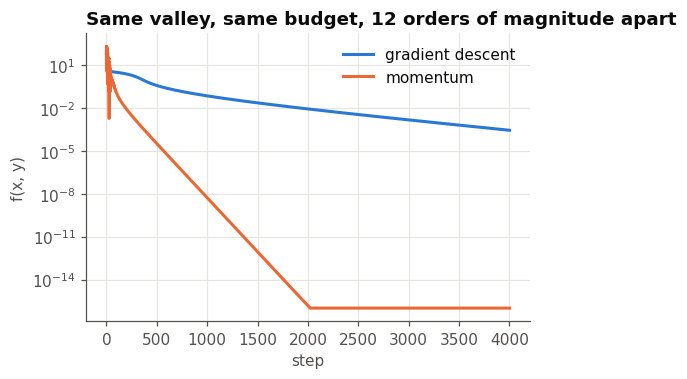

In [33]:
walks = [("gradient descent", gd_path, SERIES["Reykjavik"]),
         ("momentum", mo_path, SERIES["Lisbon"])]
final = {name: rosenbrock(path[-1]) for name, path, _ in walks}
orders = np.log10(max(final["gradient descent"], 1e-16) / max(final["momentum"], 1e-16))

fig, ax = plt.subplots()
for name, path, color in walks:
    values = np.maximum([rosenbrock(p) for p in path], 1e-16)
    ax.semilogy(values, color=color, lw=2, label=name)
ax.set(title=f"Same valley, same budget, {orders:.0f} orders of magnitude apart",
       xlabel="step", ylabel="f(x, y)")
ax.legend()
plt.show()

### B · With momentum

Keep a running velocity, so gradients that agree from step to step add up and
ones that flip sign cancel. Same start, same step size, same budget.

In [27]:
class Momentum(Descent):
    def __init__(self, lr=LR, beta=0.9):
        super().__init__(lr)
        self.beta = beta
        self.velocity = np.zeros(2)

    def step(self, p, g):
        self.velocity = self.beta * self.velocity - self.lr * g
        return p + self.velocity


mo_path = Momentum().run()
print(f"after {BUDGET} steps: {mo_path[-1].round(4)}   f = {rosenbrock(mo_path[-1]):.2e}")

after 4000 steps: [1. 1.]   f = 1.84e-30


In [28]:
checkpoints(mo_path)

,x,y,f
step,,,
0,-1.5000,1.5000,6.250000e+01
10,-0.1632,1.0448,1.050179e+02
100,0.6692,0.4387,1.177759e-01
1000,0.9999,0.9999,5.321037e-09
4000,1.0000,1.0000,1.836567e-30


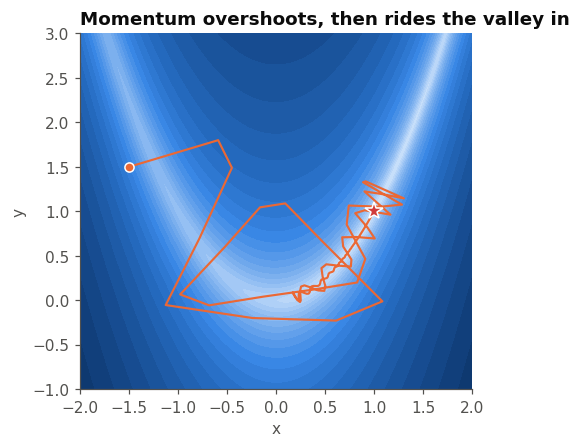

In [29]:
draw(mo_path, "Momentum overshoots, then rides the valley in", SERIES["Lisbon"])

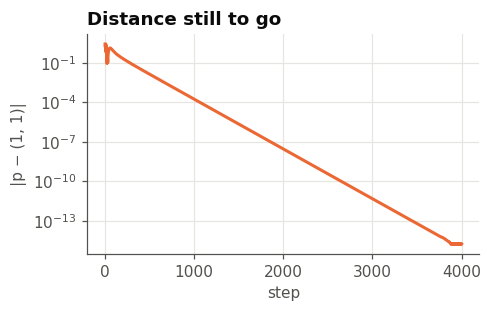

In [30]:
fig, ax = plt.subplots(figsize=(4.6, 2.6))
ax.semilogy(np.maximum(np.linalg.norm(mo_path - [1, 1], axis=1), 1e-16),
            color=SERIES["Lisbon"], lw=2)
ax.set(title="Distance still to go", xlabel="step", ylabel="|p − (1, 1)|")
plt.show()

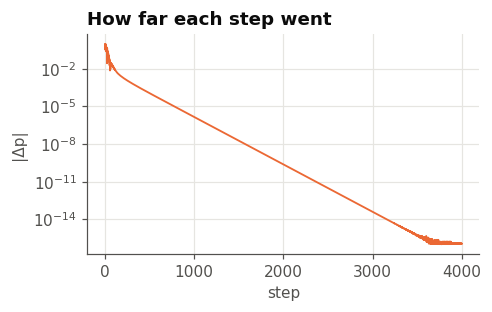

In [31]:
stride = np.linalg.norm(np.diff(mo_path, axis=0), axis=1)

fig, ax = plt.subplots(figsize=(4.6, 2.6))
ax.semilogy(np.maximum(stride, 1e-16), color=SERIES["Lisbon"], lw=1.2)
ax.set(title="How far each step went", xlabel="step", ylabel="|Δp|")
plt.show()

In [32]:
# The same walk at other step sizes: where does this strategy stop working?
rates = [0.0005, 0.001, 0.002, 0.003, 0.004]
with np.errstate(over="ignore", invalid="ignore"):
    final = [rosenbrock(Momentum(lr).run(2000)[-1]) for lr in rates]

pd.DataFrame(
    {"lr": rates,
     "f after 2000 steps": [f"{v:.2e}" if np.isfinite(v) else "diverged" for v in final]}
).set_index("lr")

,f after 2000 steps
lr,
0.0005,4.05e-05
0.0010,6.20e-09
0.0020,1.45e-16
0.0030,diverged
0.0040,diverged


Both walks against the clock. The columns above tell the story in space; this
tells it in time, on the same axes.

In [34]:
pd.DataFrame(
    {name: [*path[-1].round(4), f"{rosenbrock(path[-1]):.2e}"] for name, path, _ in walks},
    index=["x", "y", "f(x, y)"],
)

,gradient descent,momentum
x,0.9832,1.0
y,0.9666,1.0
"f(x, y)",2.83e-04,1.84e-30
